# এনসেম্বল (Ensemble)**গল্প: অনেক গাছ মিলে বন**কল্পনা করো তুমি একটি সিদ্ধান্ত নিতে একজন শিক্ষকের মতামত নিচ্ছ। কিন্তু একজন শিক্ষক ভুল করতে পারেন। তুমি যদি 10 জন শিক্ষকের মতামত নাও এবং সংখ্যাগরিষ্ঠের ভোট নাও, তাহলে সিদ্ধান্ত বেশি নির্ভুল হবে!এনসেম্বল ঠিক এটাই করে - এটি অনেক মডেল একসাথে ব্যবহার করে, এবং তাদের ভোটের ভিত্তিতে সিদ্ধান্ত নেয়। 'এক গাছ ভালো, কিন্তু বন আরও ভালো!'

## আমরা কী শিখব?1. RandomForestClassifier (র্যান্ডম ফরেস্ট)2. GradientBoostingClassifier (গ্রেডিয়েন্ট বুস্টিং)3. n_estimators (কতগুলো গাছ?)4. Feature importance: single tree vs forest

## প্রথমে লাইব্রেরি ইম্পোর্ট করি

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
print('লাইব্রেরি ইম্পোর্ট সফল হয়েছে!')

লাইব্রেরি ইম্পোর্ট সফল হয়েছে!


## Iris ডেটাসেট লোড করি

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)
print('ট্রেন সেট:', X_train.shape[0], 'নমুনা')
print('টেস্ট সেট:', X_test.shape[0], 'নমুনা')

ট্রেন সেট: 112 নমুনা
টেস্ট সেট: 38 নমুনা


## Decision Tree vs Random Forestপ্রথমে একটি single decision tree তৈরি করি, তারপর Random Forest দিয়ে তুলনা করি।

In [3]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
forest = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
forest.fit(X_train, y_train)
print('Decision Tree Test accuracy:', tree.score(X_test, y_test))
print('Random Forest Test accuracy:', forest.score(X_test, y_test))

Decision Tree Test accuracy:

 1.0
Random Forest Test accuracy: 1.0


## n_estimators-এর প্রভাবRandom Forest-এ কতগুলো গাছ (n_estimators) ব্যবহার করলে ভালো হয়? নিচে দেখা যাক।

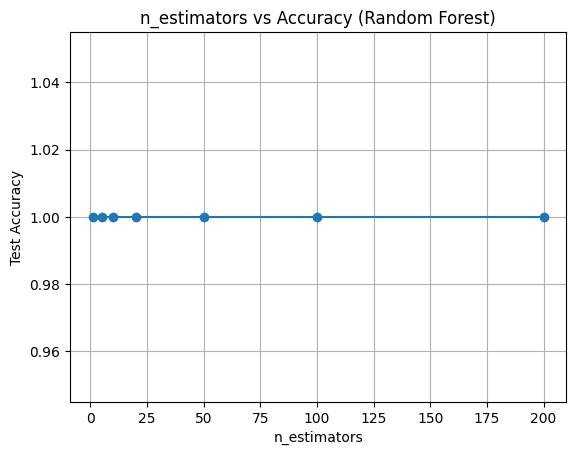

50-100 গাছের পর accuracy স্থির হয়ে যায়!


In [4]:
estimators = [1, 5, 10, 20, 50, 100, 200]
scores = []
for n in estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    scores.append(rf.score(X_test, y_test))
plt.plot(estimators, scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Test Accuracy')
plt.title('n_estimators vs Accuracy (Random Forest)')
plt.grid(True)
plt.show()
print('50-100 গাছের পর accuracy স্থির হয়ে যায়!')

## Gradient BoostingGradient Boosting আরেকটি এনসেম্বল পদ্ধতি। এটি একের পর এক গাছ তৈরি করে, যেখানে প্রতিটি নতুন গাছ আগের গাছের ভুল শুধরে।

In [5]:
gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
print('Gradient Boosting Test accuracy:', gb.score(X_test, y_test))

Gradient Boosting Test accuracy: 1.0


## তিনটি মডেলের তুলনাDecision Tree, Random Forest, Gradient Boosting - তিনটির performance তুলনা করি।

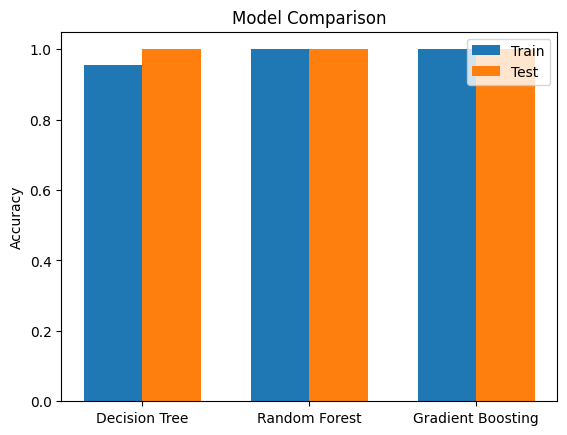

In [6]:
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}
names = []
train_accs = []
test_accs = []
for name, model in models.items():
    model.fit(X_train, y_train)
    names.append(name)
    train_accs.append(model.score(X_train, y_train))
    test_accs.append(model.score(X_test, y_test))
x = np.arange(len(names))
width = 0.35
plt.bar(x - width/2, train_accs, width, label='Train')
plt.bar(x + width/2, test_accs, width, label='Test')
plt.xticks(x, names)
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Comparison')
plt.show()

## Feature Importance: Single Tree vs Forestএকটি মাত্র গাছের feature importance আর Random Forest-এর feature importance-র তুলনা করি। Forest বেশি নির্ভরযোগ্য importance দেয়!

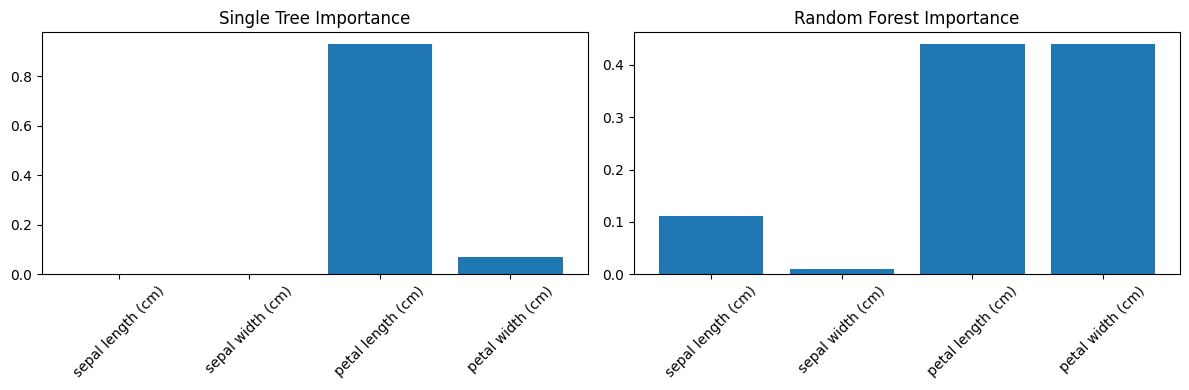

Forest-এর importance বেশি স্থিতিশীল!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(4), tree.feature_importances_)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(iris.feature_names, rotation=45)
axes[0].set_title('Single Tree Importance')
axes[1].bar(range(4), forest.feature_importances_)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(iris.feature_names, rotation=45)
axes[1].set_title('Random Forest Importance')
plt.tight_layout()
plt.show()
print('Forest-এর importance বেশি স্থিতিশীল!')

## আরও জটিল ডেটা দিয়ে Decision BoundaryRandom Forest-এর decision boundary single tree-র চেয়ে কেমন মসৃণ হয় দেখি।

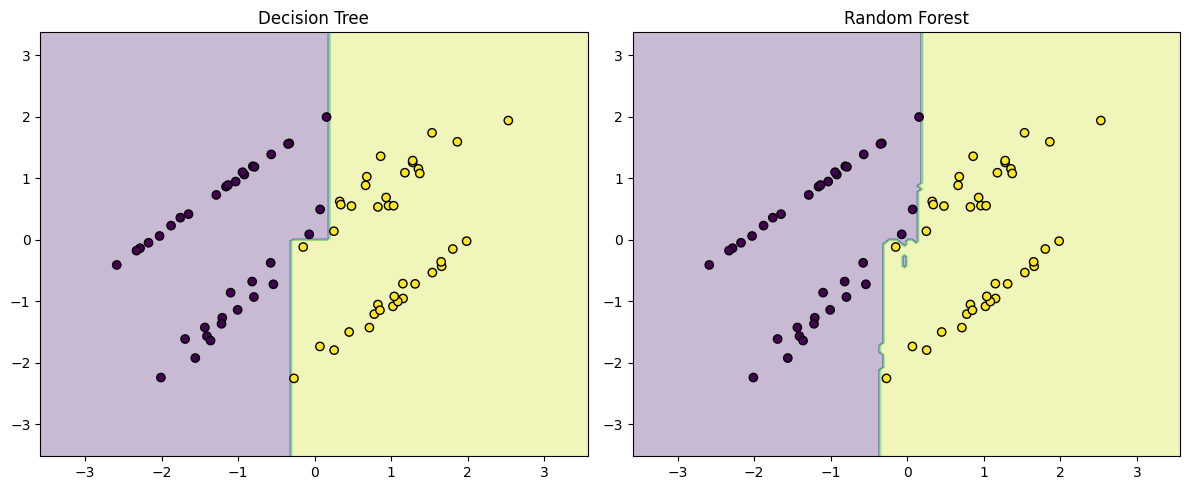

In [8]:
X2, y2 = make_classification(n_features=2, n_redundant=0,
                             n_informative=2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, random_state=42)
tree2 = DecisionTreeClassifier(random_state=42)
tree2.fit(X2_train, y2_train)
forest2 = RandomForestClassifier(n_estimators=100, random_state=42)
forest2.fit(X2_train, y2_train)
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (model, title) in enumerate([
    (tree2, 'Decision Tree'),
    (forest2, 'Random Forest')
]):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    axes[i].contourf(xx, yy, Z, alpha=0.3)
    axes[i].scatter(X2_train[:, 0], X2_train[:, 1],
                    c=y2_train, edgecolors='k')
    axes[i].set_title(title)
plt.tight_layout()
plt.show()

## সারসংক্ষেপ| মডেল | বৈশিষ্ট্য |
|-------|----------|
| Decision Tree | একটিমাত্র গাছ, overfit করে |
| Random Forest | অনেক গাছের ভোট, overfit কমায় |
| Gradient Boosting | একের পর এক গাছ, ভুল শুধরে |
এনসেম্বল মডেল single tree-র চেয়ে প্রায় সবসময় ভালো ফল দেয়!